In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [9]:
pd.set_option("display.max_columns",None)
df = pd.read_csv("/kaggle/input/datasets/mathchi/diabetes-data-set/diabetes.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

All features in the dataset have appropriate data types.

In [11]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
df.info()
df.describe()
(df == 0).sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

The dataset does not contain any explicit missing values, as all columns have 768 non-null entries. However, some features contain zero values that are not medically realistic, such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI. These zero values are treated as missing data since they likely represent unrecorded or invalid measurements.

In [27]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

Task2: Zero values were replaced with NaN as they are not realistic. Missing values were then handled using the median, as it is more robust to outliers compared to the mean.

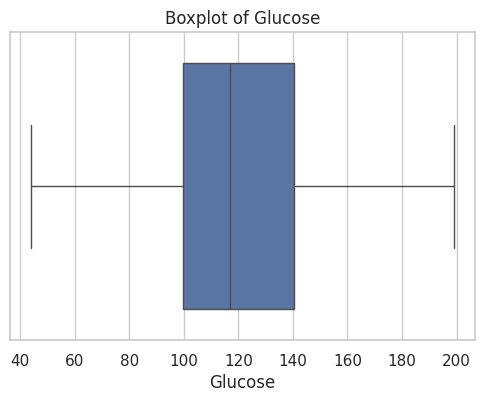

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Glucose'])
plt.title('Boxplot of Glucose')
plt.show()

In [31]:
Q1 = df['Glucose'].quantile(0.25)
Q3 = df['Glucose'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Glucose'] < lower) | (df['Glucose'] > upper)]
print(outliers.head())

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []


In [32]:
df_no_outliers = df[(df['Glucose'] >= lower) & (df['Glucose'] <= upper)]

print("Before:", df.shape)
print("After:", df_no_outliers.shape)

Before: (768, 9)
After: (768, 9)


In [33]:
outliers.shape

(0, 9)

Task 3: Outliers: The IQR method was applied to detect outliers. However, no outliers were identified in the dataset, indicating that the data is relatively clean. Therefore, no outlier removal was required.

In [37]:
lower_cap = df['Glucose'].quantile(0.05)
upper_cap = df['Glucose'].quantile(0.95)

df_capped = df.copy()
df_capped['Glucose'] = df_capped['Glucose'].clip(lower_cap, upper_cap)

In [71]:
features = df_no_outliers.drop('Outcome', axis=1)

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_minmax = scaler.fit_transform(features)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_zscore = scaler.fit_transform(features)

Task4: Min-Max scaling was used to scale values between 0 and 1, while Z-score normalization standardizes the features with mean 0 and standard deviation 1.

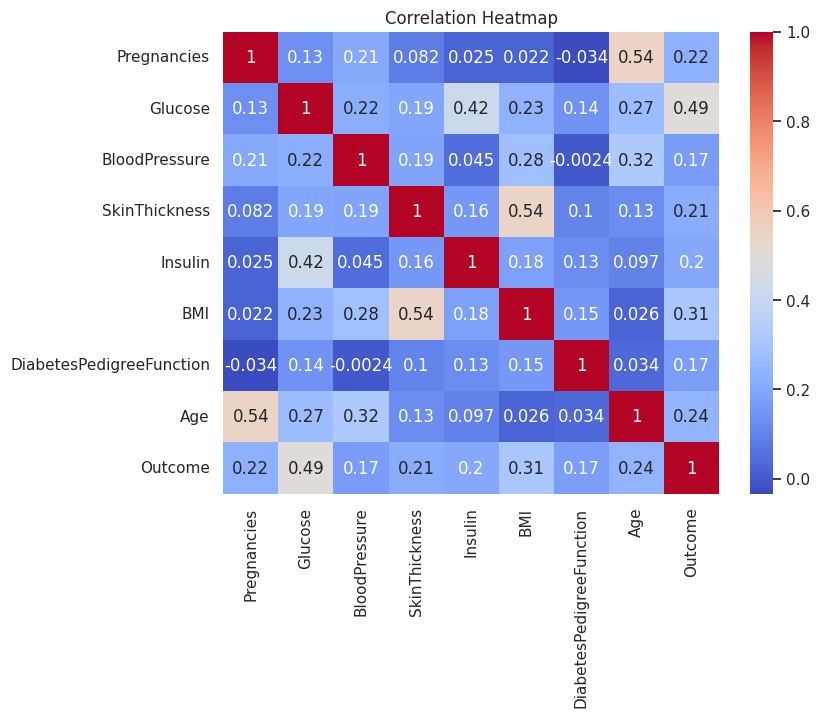

In [59]:
plt.figure(figsize=(8,6))
sns.heatmap(df_no_outliers.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [72]:
from sklearn.decomposition import PCA

X = df_no_outliers.drop('Outcome', axis=1)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.86831294 0.08725246]


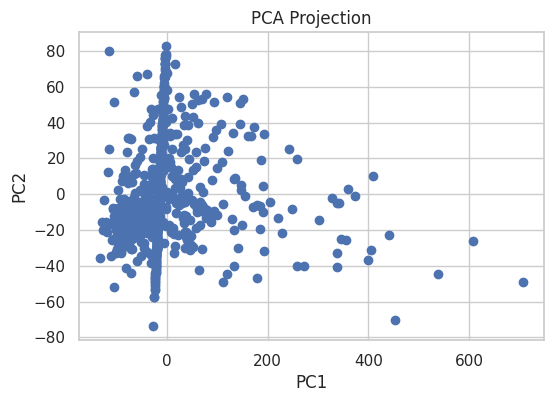

In [73]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Task5: PCA was applied because some features are correlated. It helps reduce dimensionality while preserving important information.